In [1]:
import pandas as pd
from pathlib import Path

In [6]:
import numpy as np

def compute_hist(data, bins, value_range):
    hist, _ = np.histogram(data, bins=bins, range=value_range)
    hist = hist.astype(float)
    hist += 1e-8
    hist /= hist.sum()
    return hist

def chi_square_distance(p, q):
    return np.sum((p - q) ** 2 / (p + q))

def bootstrap_chi_square(group1, group2, bins=30, n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    n = min(len(group1), len(group2))
    global_min = min(group1.min(), group2.min())
    global_max = max(group1.max(), group2.max())
    value_range = (global_min, global_max)

    distances = []

    for _ in range(n_boot):
        sample1 = rng.choice(group1, size=n, replace=True)
        sample2 = rng.choice(group2, size=n, replace=True)

        hist1 = compute_hist(sample1, bins=bins, value_range=value_range)
        hist2 = compute_hist(sample2, bins=bins, value_range=value_range)

        dist = chi_square_distance(hist1, hist2)
        distances.append(dist)

    distances = np.array(distances)

    result = {
        "mean_distance": distances.mean(),
        "std_distance": distances.std(ddof=1),
        "ci_lower": np.percentile(distances, 2.5),
        "ci_upper": np.percentile(distances, 97.5),
        "all_distances": distances
    }
    return result

In [7]:

OUTPUT_DIR = Path("./outputs")

resnet_df = pd.read_csv(OUTPUT_DIR / "resnet_pairwise_similarity.csv")
densenet_df = pd.read_csv(OUTPUT_DIR / "densenet_pairwise_similarity.csv")

In [8]:
resnet_same = resnet_df[resnet_df["label1"] == resnet_df["label2"]]["cosine_similarity"].values
resnet_cross = resnet_df[resnet_df["label1"] != resnet_df["label2"]]["cosine_similarity"].values

densenet_same = densenet_df[densenet_df["label1"] == densenet_df["label2"]]["cosine_similarity"].values
densenet_cross = densenet_df[densenet_df["label1"] != densenet_df["label2"]]["cosine_similarity"].values

In [9]:
resnet_result = bootstrap_chi_square(
    resnet_same, resnet_cross,
    bins=30, n_boot=1000, random_state=42
)

densenet_result = bootstrap_chi_square(
    densenet_same, densenet_cross,
    bins=30, n_boot=1000, random_state=42
)

In [10]:
print("ResNet")
print(f"Mean chi-square distance: {resnet_result['mean_distance']:.6f}")
print(f"Std: {resnet_result['std_distance']:.6f}")
print(f"95% CI: [{resnet_result['ci_lower']:.6f}, {resnet_result['ci_upper']:.6f}]")

print("\nDenseNet")
print(f"Mean chi-square distance: {densenet_result['mean_distance']:.6f}")
print(f"Std: {densenet_result['std_distance']:.6f}")
print(f"95% CI: [{densenet_result['ci_lower']:.6f}, {densenet_result['ci_upper']:.6f}]")

ResNet
Mean chi-square distance: 0.124931
Std: 0.027457
95% CI: [0.076955, 0.183934]

DenseNet
Mean chi-square distance: 0.137805
Std: 0.028145
95% CI: [0.084456, 0.192728]


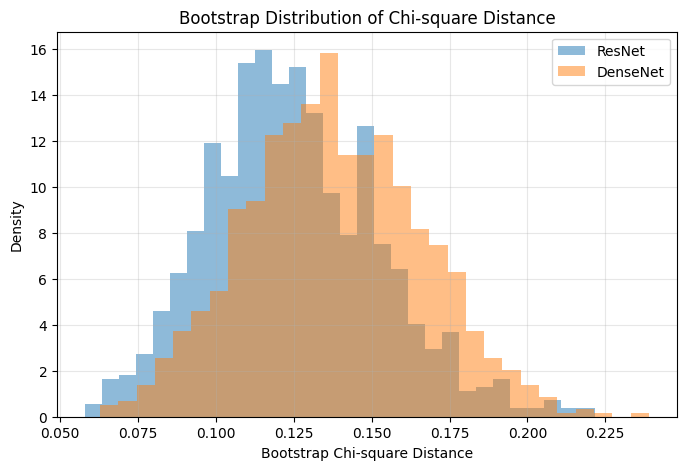

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(resnet_result["all_distances"], bins=30, alpha=0.5, density=True, label="ResNet")
plt.hist(densenet_result["all_distances"], bins=30, alpha=0.5, density=True, label="DenseNet")

plt.xlabel("Bootstrap Chi-square Distance")
plt.ylabel("Density")
plt.title("Bootstrap Distribution of Chi-square Distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()